/var/folders/yy/x3xnftks6tbf0fdc9_zm71y80000gn/T/ipykernel_36812/1600241953.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


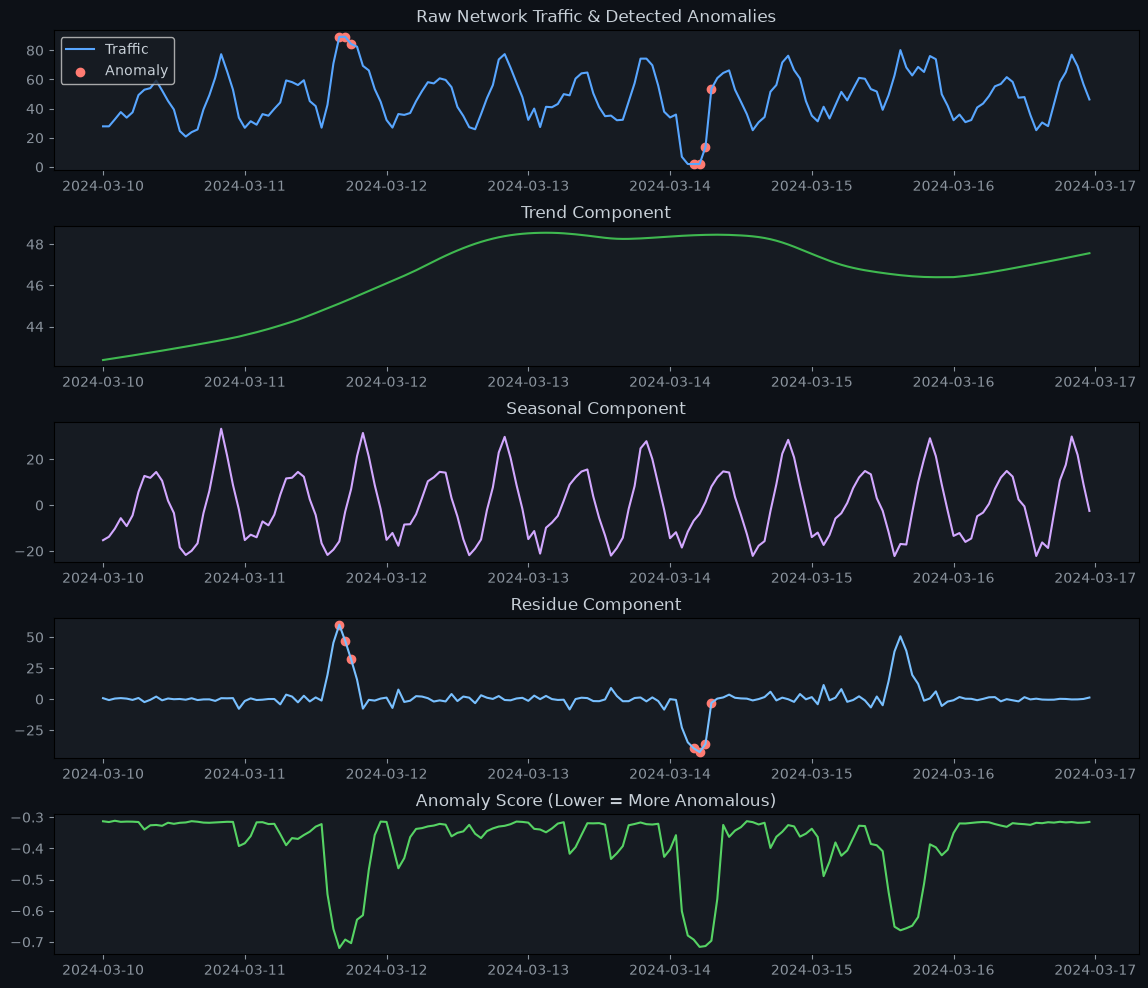

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Generate Synthetic Data
np.random.seed(42)
N = 168
hours = np.arange(N)

def daily_pattern(h):
    h_mod = h % 24
    morning_peak = 35 * np.exp(-0.5 * ((h_mod - 9) / 2.5) ** 2)
    evening_peak = 50 * np.exp(-0.5 * ((h_mod - 20) / 2.0) ** 2)
    night_base   = 10 * np.exp(-0.5 * ((h_mod - 3) / 3.0) ** 2)
    return morning_peak + evening_peak + night_base + 20

seasonal = np.array([daily_pattern(h) for h in hours])
trend = 5 * np.sin(hours * np.pi / N) + 0.02 * hours
noise = np.random.normal(0, 3.5, N)
traffic = seasonal + trend + noise

# Add anomalies
traffic[38:44] += np.array([18, 42, 55, 48, 30, 15])
traffic[133:139] += np.array([12, 35, 45, 38, 22, 10])
traffic[98:103] -= np.array([30, 55, 60, 52, 35])
traffic[98:103]  = np.maximum(traffic[98:103], 2)

# 2. DataFrame
timestamps = pd.date_range("2024-03-10 00:00", periods=N, freq="h")
df = pd.DataFrame({"Traffic_Mbps": traffic}, index=timestamps)

# 3. STL Decomposition
stl = STL(df["Traffic_Mbps"], period=24, robust=True)
result = stl.fit()
df["Trend"], df["Seasonal"], df["Residue"] = result.trend, result.seasonal, result.resid

# 4. Anomaly Detection
df["Residue_abs"] = df["Residue"].abs()
df["Residue_lag1"] = df["Residue"].shift(1).fillna(0)
df["Residue_lag2"] = df["Residue"].shift(2).fillna(0)
X = df[["Residue", "Residue_abs", "Residue_lag1", "Residue_lag2"]].values
X_scaled = StandardScaler().fit_transform(X)

iso_forest = IsolationForest(contamination=0.04, random_state=42)
df["Anomaly_Flag"] = iso_forest.fit_predict(X_scaled)
df["Anomaly_Score"] = iso_forest.score_samples(X_scaled)
anomalies = df[df["Anomaly_Flag"] == -1]

# 5. Plotting
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.facecolor": "#0D1117", "axes.facecolor": "#161B22", "text.color": "#C9D1D9", "axes.labelcolor": "#C9D1D9", "xtick.color": "#8B949E", "ytick.color": "#8B949E"})

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 1, hspace=0.4)

# Panel 1: Raw Traffic
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df["Traffic_Mbps"], color="#58A6FF", label="Traffic")
ax1.scatter(anomalies.index, anomalies["Traffic_Mbps"], color="#FF7B72", label="Anomaly")
ax1.set_title("Raw Network Traffic & Detected Anomalies")
ax1.legend()

# Panel 2: Trend
ax2 = fig.add_subplot(gs[1])
ax2.plot(df.index, df["Trend"], color="#3FB950")
ax2.set_title("Trend Component")

# Panel 3: Seasonal
ax3 = fig.add_subplot(gs[2])
ax3.plot(df.index, df["Seasonal"], color="#D2A8FF")
ax3.set_title("Seasonal Component")

# Panel 4: Residue
ax4 = fig.add_subplot(gs[3])
ax4.plot(df.index, df["Residue"], color="#79C0FF")
ax4.scatter(anomalies.index, anomalies["Residue"], color="#FF7B72")
ax4.set_title("Residue Component")

# Panel 5: Anomaly Score
ax5 = fig.add_subplot(gs[4])
ax5.plot(df.index, df["Anomaly_Score"], color="#56D364")
ax5.set_title("Anomaly Score (Lower = More Anomalous)")

plt.tight_layout()
plt.savefig("anomaly_detection_plot.png", dpi=150)
plt.show()